Regressione lineare in python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression


In [2]:
# con as_frame=true, ritorna direttamente un df pandas
data = fetch_california_housing(as_frame=True)
df = data.frame
print(f"Features: {data.feature_names}")
print(df.head())

X = df[data.feature_names]
y = df["MedHouseVal"]

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [4]:
print(f"Intercetta: {model.intercept_}")
print(f"Feature coefficients:")
for name, coef in zip(data.feature_names, model.coef_):
    print(f"  {name}: {coef:.4f}")

Intercetta: -36.94192020718454
Feature coefficients:
  MedInc: 0.4367
  HouseAge: 0.0094
  AveRooms: -0.1073
  AveBedrms: 0.6451
  Population: -0.0000
  AveOccup: -0.0038
  Latitude: -0.4213
  Longitude: -0.4345


In [5]:
# label predette con il metodo predict

y_pred = model.predict(X)

In [6]:
# calcolo mae

mae = np.mean(np.abs(y - y_pred))
print(f"Mean Absolute Error: {mae:.3f}")

Mean Absolute Error: 0.531


In [7]:
# alternativamente possiamo verificare la tolleranza

toll = 0.5
good_pred = np.mean(np.abs(y - y_pred) < toll)
print(f"Percentage Good Predictions (MAE < {toll}): {good_pred:.2%}")

Percentage Good Predictions (MAE < 0.5): 58.82%


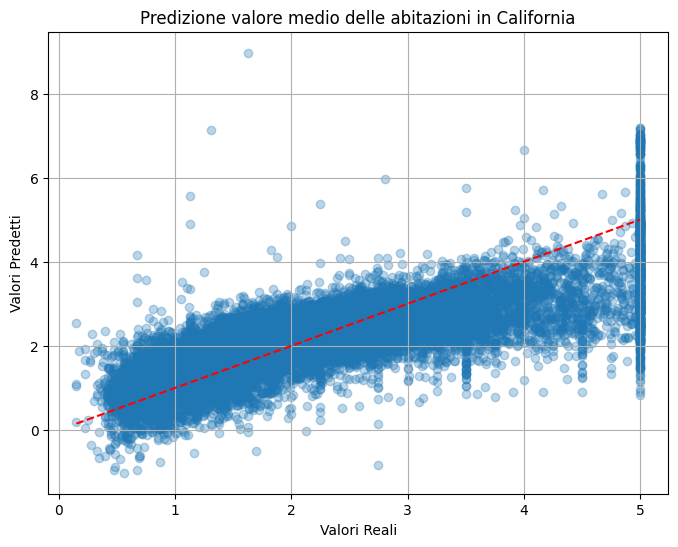

In [8]:
# rappresentazione grafica

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")  # linea di regressione
plt.xlabel("Valori Reali")
plt.ylabel("Valori Predetti")
plt.title("Predizione valore medio delle abitazioni in California")
plt.grid()
plt.show()

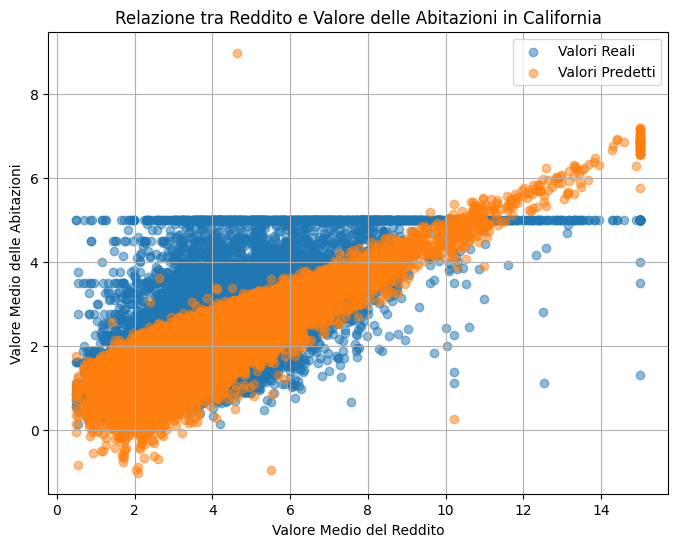

In [9]:
# plot per vedere valore medio del reddito e delle abitazioni (ipotesi più sensata)

plt.figure(figsize=(8, 6))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.5, label="Valori Reali")
plt.scatter(df["MedInc"], y_pred, alpha=0.5, label="Valori Predetti")
plt.xlabel("Valore Medio del Reddito")
plt.ylabel("Valore Medio delle Abitazioni")
plt.title("Relazione tra Reddito e Valore delle Abitazioni in California")
plt.legend()
plt.grid()
plt.show()

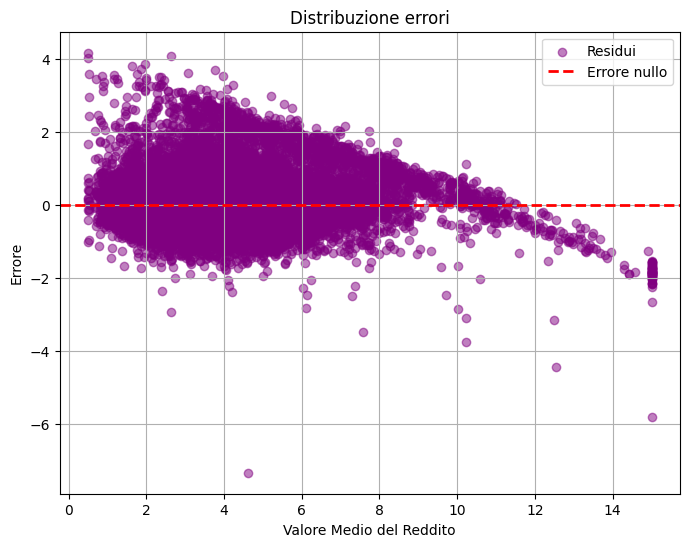

In [10]:
# rappresentazione grafica errore in base al medInc

error = y.squeeze() - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(X["MedInc"], error, color="purple", alpha=0.5, label="Residui")
plt.axhline(y = 0, color="red", linestyle="--", linewidth=2, label="Errore nullo")
plt.xlabel("Valore Medio del Reddito")
plt.ylabel("Errore")
plt.title("Distribuzione errori")
plt.legend()
plt.grid()
plt.show()